# Projectile Motion Simulator Demo

Interactive simulation of 2D projectile motion with and without quadratic air drag.

In [1]:
# Install the package (run once)
# !pip install -e ..   # if running from notebooks/

import sys
sys.path.append('..')  # temporary for development

from projectilemotion import (
    update_simulation,
    plot_simulation,
    create_animation,
    # add other functions you have
)

import matplotlib.pyplot as plt
%matplotlib inline

## Quick Start Plot

Running a single simulation using the package to visualize the results.

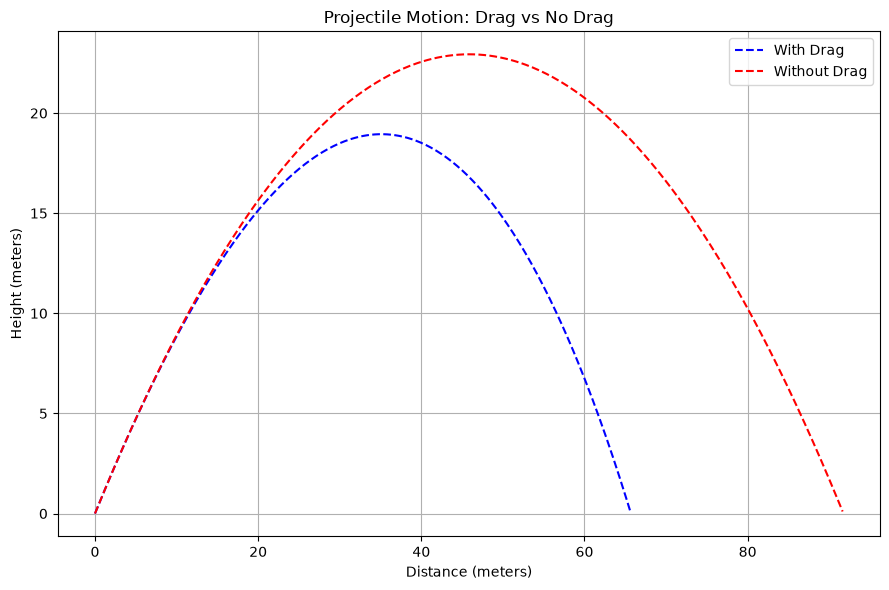

In [2]:
# Simple simulation example
results = update_simulation(
    m=0.145,      # kg (baseball)
    c=0.00086,    # drag coefficient
    angle=45,     # degrees
    v_0=30,       # m/s
    y_0=0,        # meters
)

fig, ax = plot_simulation(results, show_nodrag_path=True)
plt.show()

## Interactive Simulation

Using the widgets below to explore different scenarios in real time

In [5]:
# === Enhanced Interactive UI with Presets, GIF, CSV, Progress Bar ===

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.notebook import tqdm
import time

# Optional: tqdm for nice progress bar
try:
    from tqdm.notebook import tqdm
    tqdm_available = True
except ImportError:
    tqdm_available = False
    print("tqdm not installed. Using simple progress bar instead.")
    # You can install it with: !pip install tqdm
    
# Presets
presets = {
    "Ping-Pong Ball": {"m": 0.0027, "c": 0.000362, "v_0": 30},
    "Baseball": {"m": 0.145, "c": 0.00084, "v_0": 50},
    "Soccerball": {"m": 0.450, "c": 0.00582, "v_0": 40},
    "Coconut": {"m": 2.00, "c": 0.00701, "v_0": 35},
    "Shotput": {"m": 7.26, "c": 0.00324, "v_0": 25},
    "Large Cannonball": {"m": 14.51, "c": 0.00443, "v_0": 60},
}

def run_interactive(m=0.145, c=0.00086, angle=45.0, v_0=30.0, y_0=0.0, drag=True, save_gif=False):
    """Improved version with better progress feedback"""
    drag_c = c if drag else 0.0

    progress_output = widgets.Output()
    display(progress_output)
    
    with progress_output:   # Make sure output is visible during computation
        print("Starting simulation...")
        
        # Progress bar for the heavy parts
        if tqdm_available:
            with tqdm(total=100, desc="Computing Trajectory", bar_format="{l_bar}{bar} {n_fmt}% [{elapsed}<{remaining}]") as pbar:
                # Phase 1: Numerical integration
                pbar.set_description("Solving ODE...")
                results = update_simulation(
                    m=m, c=drag_c, angle=angle, v_0=v_0, y_0=y_0
                )
                pbar.update(60)  # 60% for simulation
                
                # Phase 2: Plot setup
                pbar.set_description("Creating plots...")
                fig, ax = plot_simulation(results, show_nodrag_path=True)
                pbar.update(20)
                
                # Phase 3: Animation
                pbar.set_description("Rendering Animation...")
                anim = create_animation(fig, ax, results)
                pbar.update(20)
        else:
            # Fallback without tqdm
            print("Solving ODE...", end=" ")
            results = update_simulation(m=m, c=drag_c, angle=angle, v_0=v_0, y_0=y_0)
            print("Creating plots & animation...")
            fig, ax = plot_simulation(results, show_nodrag_path=True)
            anim = create_animation(fig, ax, results)

    
    time.sleep(0.4)

    progress_output.clear_output()
    progress_output.close()
  
    # Display the animation
    display(HTML(anim.to_jshtml()))
    
    # Summary
    print(f"\nWith Drag    → Range: {results.get('x_impact', 0):.2f} m | "
          f"Impact Speed: {results.get('v_impact', 0):.2f} m/s")
    print(f"No Drag      → Range: {results.get('x_nd_impact', 0):.2f} m | "
          f"Impact Speed: {results.get('v_nd_impact', 0):.2f} m/s")
    
    return results, fig, anim


# === Widgets ===
style = {'description_width': 'initial'}

preset_dropdown = widgets.Dropdown(
    options=list(presets.keys()), value="Baseball", description='Preset:', style=style
)

m_slider = widgets.FloatSlider(value=0.145, min=0.01, max=20, step=0.001, description='Mass (kg)', style=style)
c_slider = widgets.FloatSlider(value=0.00084, min=0, max=0.01, step=0.00001, description='Drag Coeff (c)', style=style)
angle_slider = widgets.FloatSlider(value=45, min=0, max=90, step=0.1, description='Launch Angle (°)', style=style)
v_0_slider = widgets.FloatSlider(value=50, min=1, max=150, step=0.1, description='Initial Speed (m/s)', style=style)
y_0_slider = widgets.FloatSlider(value=0, min=0, max=100, step=0.1, description='Initial Height (m)', style=style)

drag_check = widgets.Checkbox(value=True, description='Include Quadratic Drag')

run_button = widgets.Button(description="Run", button_style='success')
save_gif_button = widgets.Button(description="Save GIF", button_style='info')
export_csv_button = widgets.Button(description="Export CSV", button_style='info')
reset_button = widgets.Button(description="Reset", button_style='warning')
sweep_button = widgets.Button(description="Angle Sweep", button_style='primary')

output = widgets.Output()

# Preset handler
def on_preset_change(change):
    if change['name'] == 'value':
        p = presets[change['new']]
        m_slider.value = p['m']
        c_slider.value = p['c']
        v_0_slider.value = p.get('v_0', 50)

preset_dropdown.observe(on_preset_change, names='value')

# Button handlers
def on_run_clicked(b):
    with output:
        output.clear_output()
        run_interactive(
            m=m_slider.value,
            c=c_slider.value,
            angle=angle_slider.value,
            v_0=v_0_slider.value,
            y_0=y_0_slider.value,
            drag=drag_check.value
        )

def on_save_gif_clicked(b):
    with output:
        output.clear_output()
        results, fig, anim = run_interactive(
            m=m_slider.value, c=c_slider.value, angle=angle_slider.value,
            v_0=v_0_slider.value, y_0=y_0_slider.value, drag=drag_check.value, save_gif=True
        )
        # Try to save GIF if your animation function supports it
        try:
            anim.save('projectile_trajectory.gif', writer='pillow', fps=30)
            print("GIF saved as 'projectile_trajectory.gif'")
        except Exception as e:
            print(f"Could not save GIF: {e}")

def on_export_csv_clicked(b):
    with output:
        output.clear_output()
        results, _, _ = run_interactive(
            m=m_slider.value, c=c_slider.value, angle=angle_slider.value,
            v_0=v_0_slider.value, y_0=y_0_slider.value, drag=drag_check.value
        )
        # Adjust keys based on your actual results dict
        df = pd.DataFrame({
            'time': results.get('t', []),
            'x': results.get('x', []),
            'y': results.get('y', []),
            'vx': results.get('vx', []),
            'vy': results.get('vy', [])
        })
        filename = f"projectile_{preset_dropdown.value.lower()}_{int(angle_slider.value)}deg.csv"
        df.to_csv(filename, index=False)
        print(f"Exported to {filename}")

def on_reset_clicked(b):
    preset_dropdown.value = "Baseball"

# Attach callbacks
run_button.on_click(on_run_clicked)
save_gif_button.on_click(on_save_gif_clicked)
export_csv_button.on_click(on_export_csv_clicked)
reset_button.on_click(on_reset_clicked)

# Final Layout
controls = widgets.VBox([
    preset_dropdown,
    widgets.HBox([m_slider, c_slider]),
    widgets.HBox([angle_slider, v_0_slider]),
    y_0_slider,
    drag_check,
    widgets.HBox([run_button, reset_button, sweep_button, save_gif_button, export_csv_button]),
    output
])

display(controls)

## Angle Sweep Analysis

Find the optimal launch angle for maximum range.

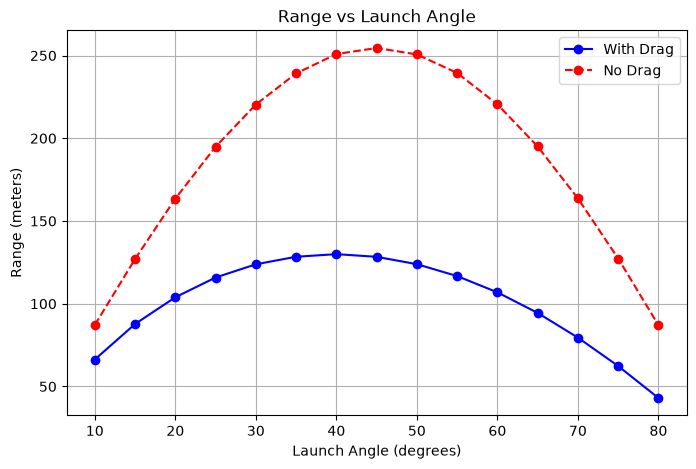

Best angle with drag ≈ 40°


In [4]:
import numpy as np

angles = np.arange(10, 81, 5)
ranges = []
ranges_nd = []

for ang in angles:
    res = update_simulation(angle=ang, v_0=50)
    ranges.append(res['x_impact'])
    ranges_nd.append(res['x_nd_impact'])

plt.figure(figsize=(8, 5))
plt.plot(angles, ranges, 'b-o', label='With Drag')
plt.plot(angles, ranges_nd, 'r--o', label='No Drag')
plt.xlabel('Launch Angle (degrees)')
plt.ylabel('Range (meters)')
plt.title('Range vs Launch Angle')
plt.grid(True)
plt.legend()
plt.show()

print(f"Best angle with drag ≈ {angles[np.argmax(ranges)]}°")

## Validation & Key Insights

- Energy conservation is monitored.
- No-drag case matches analytical solution closely.
- Drag significantly reduces range, especially at higher speeds/angles.

## Next Steps & Further Reading

- Full physics derivations: [Physics_Background.md](../docs/Physics_Background.md)
- Source code: [`src/projectilemotion/`](../src/projectilemotion/)
- Run `test_sim.py` for automated checks.

This notebook demonstrates how to **use** the professional package. All heavy computation lives in the `src/` modules.